#### Βήμα 1: Φόρτωση και Προεπεξεργασία
### 1α. Φόρτωση dataset
Μετά τις βιβλιοθήκες, φορτώνουμε το Enron Email Dataset.
Αποτελείται από 5572 email, αποθηκευμένα με την εξής μορφή:\
Category,Message\
Υπάρχουν 4825 ham emails και 747 spam emails.
### 1β. Προεπεξεργασία
Το dataset περνάει προεπεξεργασία. 
Πρώτα, αφαιρούμε τα URLs με μια κανονική έκφραση.
Μετά αφαιρούμε τα emoticons, πάλι με κανονική έκφραση.
Με την ίδια λογική αφαιρούμε τους αριθμούς.
Κάνουμε lowercasing και αντικαθιστούμε τους ειδικούς χαρακτήρες με κενά.
Μετά, αφαιρούμε ότι διπλά whitespaces δημιουργήθηκαν.\
Έπειτα, με έτοιμες συναρτήσεις, γίνεται το tokenization, stopword removal, lemmatization, και τέλος επιστρέφονται τα tokens ως ένα ενιαίο string.
### 1γ. Τελική προεπεξεργασία
Πριν επεξεργαστεί από τους τρεις αλγορίθμους, το dataset γίνεται vector για να μπορεί να επεξεργαστεί, και χωρίζεται σε 5 folds ώστε να μπορεί να εξεταστεί ενάντια στον εαυτό του (cross validation). Τα folds είναι στρωματοποιημένα (stratified), έτσι ώστε κάθε ένα να έχει ίδιο ποσοστό spam και ham.

In [8]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
import emoji
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
import time

# Load the dataset
df = pd.read_csv('mail_data.csv', encoding='latin-1')

df.columns = ['Category', 'Message']

print("\nRaw Data Sample:")
print(df.iloc[[122]])
print(df.iloc[[191]])
print("\nCategory distribution:")
print(df['Category'].value_counts())

def preprocess_text(text):
    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 2. Remove most emoticons
    text = re.sub(r'[8:=;][-o*]?[\)\(DOPpS\/\\\]]', '', text)
    # 3. Remove Numbers
    text = re.sub(r'\d+', '', text)
    # 4. Convert to lowercase
    text = text.lower()
    # 5. Replace special characters with whitespace
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    # 6. Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    # 7. Tokenization
    tokens = word_tokenize(text)
    # 8. Remove Stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # 9. Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Join tokens back into a string
    text = ' '.join(tokens)
    return text
    
df['Message'] = df['Message'].apply(preprocess_text)

# Map categories to numbers
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

X = df['Message']
y = df['Category']

print("\nProcessed Data Sample:")
print(X.iloc[[122]])
print(X.iloc[[191]])

# Vectorize the text data
X_train = X
y_train = y
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']


Raw Data Sample:
    Category                                            Message
122      ham  here is my new address -apples&pairs&all that ...
    Category                                            Message
191     spam  Are you unique enough? Find out from 30th Augu...

Category distribution:
Category
ham     4825
spam     747
Name: count, dtype: int64

Processed Data Sample:
122    new address apple pair malarky
Name: Message, dtype: object
191    unique enough find th august
Name: Message, dtype: object


#### Βήμα 2: Παραδοσιακή προσέγγιση με Naive Bayes
### 2α. Αλγόριθμος και εκπαίδευση
Χρησιμοποιούμε τον αλγόριθμο MultinomialNB, του sklearn. Εκπαιδεύεται στο dataset με μία εντολή.\
Για τα αποτελέσματα όλων των αλγορίθμων, χρησιμοποιείται το cross_validate για να κάνει cross validation στο dataset.
### Αποτελέσματα
Εξετάζουμε τις εξής μετρικές: accuracy, precision, recall, και f1-Score. Πιστεύουμε ότι αυτές οι μετρικές μας δίνουν μια ικανοποιητική εικόνα στην απόδοση του αλγορίθμου.\
Επίσης, σε κάθε αλγόριθμο παράγεται το confusion matrix από το cross_val_predict και το confusion_matrix.


--- Naive Bayes Classifier ---
Training Time: 0.0129 seconds

Cross-Validation Results:
Accuracy: 0.9645
Precision: 0.9945
Recall: 0.7389
F1-Score: 0.8476


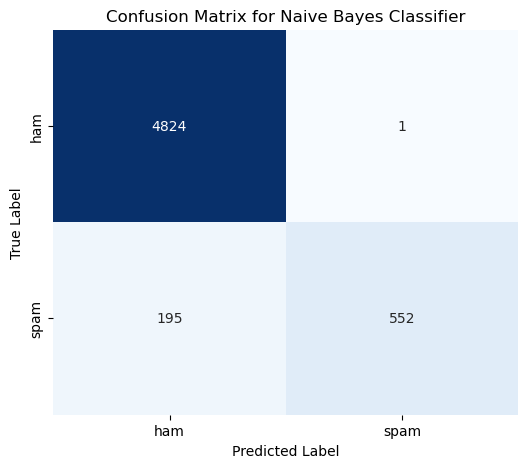

In [9]:
print("\n--- Naive Bayes Classifier ---")
start_time = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = cross_val_predict(nb_model, X_train_tfidf, y_train, cv=5)
end_time = time.time()
nb_time = end_time - start_time
print(f"Training Time: {nb_time:.4f} seconds")

# Cross validate predictions
# The Stratified K-fold splits the training set into K folds, with the same percentage of spam and ham in them.

cv_results_nb = cross_validate(nb_model, X_train_tfidf, y_train, cv=cv, scoring=scoring, n_jobs=-1)

# Print the cross-validation results
print("\nCross-Validation Results:")
print(f"Accuracy: {np.mean(cv_results_nb['test_accuracy']):.4f}")
print(f"Precision: {np.mean(cv_results_nb['test_precision']):.4f}")
print(f"Recall: {np.mean(cv_results_nb['test_recall']):.4f}")
print(f"F1-Score: {np.mean(cv_results_nb['test_f1']):.4f}")

cm = confusion_matrix(y_train, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.show()

#### Βήμα 3: Προσέγγιση με embeddings με Word2Vec και Logistic Regression
Το word2vec απαιτεί tokens, οπότε πρέπει να ξανασπάσουμε το dataset μας σε tokens.\
Το word2vec χρησιμοπιεί CBOW, καθώς είναι γρηγότερο στην εκπαίδευσή του και διαχειρίζεται καλύτερα τις προτάσεις μικρού μήκους, όπως είναι οι περισσότερες στο dataset.\
Για classifier, επιλέξαμε το Logistic Regression, λόγω της ταχύτητάς του. Αναγκαστικά, θα έχει μικρότερη αποτελεσματικότητα από άλλα classifiers, όπως το Random Forest.


--- Word2Vec with Logistic Regression ---
Training Time: 0.9235 seconds

Cross-Validation Results:
Accuracy: 0.9575
Precision: 0.9777
Recall: 0.6988
F1-Score: 0.8148


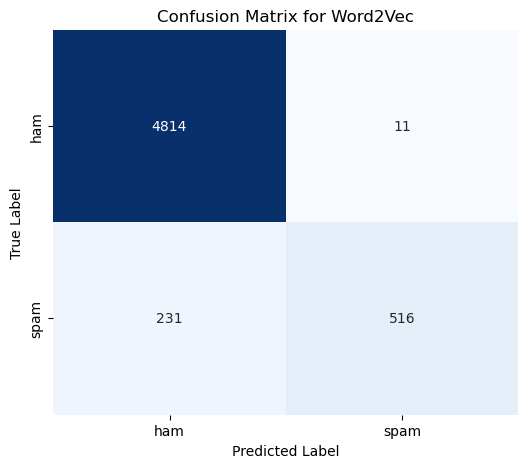

In [10]:
print("\n--- Word2Vec with Logistic Regression ---")
start_time = time.time()
# Tokenize X_train for Word2Vec training
X_train_tokens = [word_tokenize(message) for message in X_train]


# This word2vec uses CBOW (sg=0).
word2vec_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, workers=4, sg=0)
word2vec_model.train(X_train_tokens, total_examples=word2vec_model.corpus_count, epochs=10)


# Function to create document vectors by averaging word vectors
def get_document_vector(tokens, model):
    vectors = []
    for word in tokens:
        if word in model.wv:  # Check if the word is in the model's vocabulary
            vectors.append(model.wv[word])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words are found in the vocabulary
        return np.zeros(model.vector_size)

# Create document vectors for training and test sets
X_train_w2v = np.array([get_document_vector(tokens, word2vec_model) for tokens in X_train_tokens])

# Train a Logistic Regression model
# LR models are the fastest, but are a bit less accurate and precise from other models, like Random Forest.
lr_model = LogisticRegression(max_iter=1000, solver='liblinear')
lr_model.fit(X_train_w2v, y_train)

# Make predictions
y_pred_lr = cross_val_predict(lr_model, X_train_tfidf, y_train, cv=5)

end_time = time.time()
lr_time = end_time - start_time
print(f"Training Time: {lr_time:.4f} seconds")

cv_results_lr = cross_validate(lr_model, X_train_tfidf, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("\nCross-Validation Results:")
print(f"Accuracy: {np.mean(cv_results_lr['test_accuracy']):.4f}")
print(f"Precision: {np.mean(cv_results_lr['test_precision']):.4f}")
print(f"Recall: {np.mean(cv_results_lr['test_recall']):.4f}")
print(f"F1-Score: {np.mean(cv_results_lr['test_f1']):.4f}")

cm = confusion_matrix(y_train, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Word2Vec')
plt.show()

#### Βήμα 4: Βαθιά Μάθηση με Multi-Layer Perceptron
Χρησιμποοιήσαμε ένα Multi-Layer Perceptron λόγω της απλότητάς του και το σχετικά μικρό χρόνο εκπαίδευσής του.\
Οι παράμετροι είναι οι προεπιλεγμένες ρυθμίσεις του αλγορίθμου. Πειράματα με άλλες συναρτήσεις ενεργοποίησης και ρυθμιστές βάρους δεν έβγαλαν αρκετά διαφορετικά αποτελέσματα ώστε να θεωρηθούν σημαντικά.\
Η εκπαίδευση μπορεί να κρατήσει μέχρι 300 εποχές, αλλά σταματάει πρόωρα εάν δεν υπάρξει αλλαγή στο validation score για 10 εποχές.


--- Multi-Layer Perceptron (MLP) Classifier ---

Training MLP Classifier...
Training Time: 61.4632 seconds

Cross-Validation Results:
Accuracy: 0.9801
Precision: 0.9863
Recall: 0.8634
F1-Score: 0.9203


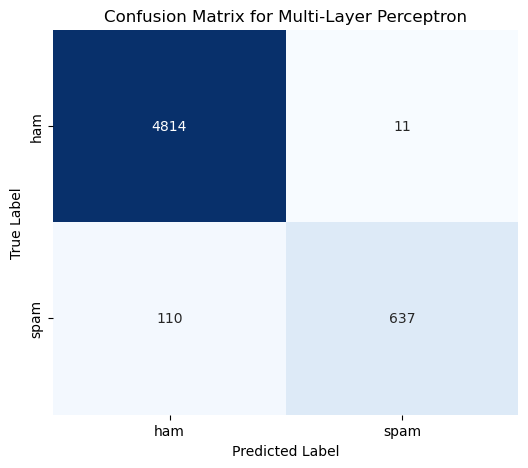

In [11]:
print("\n--- Multi-Layer Perceptron (MLP) Classifier ---")
start_time = time.time()
# Initialize the MLP Classifier
# hidden_layer_sizes: A tuple, where the i-th element represents the number of neurons in the i-th hidden layer.
# activation: Activation function for the hidden layer. 'relu' is common.
# solver: The algorithm for weight optimization. 'adam' is a good default.
# alpha: L2 penalty (regularization term) parameter.
# max_iter: Maximum number of iterations (epochs) to run.
# random_state: For reproducibility.
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', alpha=0.0001,
                          max_iter=300, random_state=42, verbose=False, early_stopping=True, n_iter_no_change=10)

# Train the MLP model
print("\nTraining MLP Classifier...")
mlp_model.fit(X_train_tfidf, y_train)

y_pred_mlp = cross_val_predict(mlp_model, X_train_tfidf, y_train, cv=5)

end_time = time.time()
mlp_time = end_time - start_time
print(f"Training Time: {mlp_time:.4f} seconds")

cv_results_mlp = cross_validate(mlp_model, X_train_tfidf, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("\nCross-Validation Results:")
print(f"Accuracy: {np.mean(cv_results_mlp['test_accuracy']):.4f}")
print(f"Precision: {np.mean(cv_results_mlp['test_precision']):.4f}")
print(f"Recall: {np.mean(cv_results_mlp['test_recall']):.4f}")
print(f"F1-Score: {np.mean(cv_results_mlp['test_f1']):.4f}")

cm = confusion_matrix(y_train, y_pred_mlp)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Multi-Layer Perceptron')
plt.show()

#### Βήμα 5: Σύγκριση
Τέλος, συγκρίνουμε τις μετρικές μας και τις οπτικοποιούμε με διαγράμματα μπάρας.
### Accuracy
Οι τιμές είναι υψηλές και στους τρεις αλγορίθμους, με το MLP να έχει το μεγαλύτερο accuracy (0.9801). Ένα χαμηλό accuracy είναι δείγμα ενός αλγορίθμου που δεν έχει εκπαιδευτεί σωστά, οπότε τιμές από 0.96 μέχρι 0.98 είναι ένα καλό πρώτο βήμα.
### Precision
O Naive Bayes έχει σχεδον τέλεια ακρίβεια (0.9945), ακόμα καλύτερη και απο το MLP (0.9863). Αν και φαίνεται πολύ καλό αποτέλεσμα, η ανάκτηση δείχνει ότι αυτή η ακρίβεια είχε ένα μεγάλο κόστος.
### Recall
Στην ανάκληση, ο Word2Vec (0.6988) και ο Naive Bayes (0.7389) υστερούν σημαντικά του MLP (0.8634). Καταλαβαίνουμε ότι ο Naive Bayes έχει μεν λίγα False Positives, αλλά έτσι παράγει πολλά False Negatives.
### F1-score
Στην ανάλυση του F1-score, καταλαβαίνουμε ότι η χαμηλή ανάκτηση των γραμμικών αλγορίθμων τους μειώνει αισθητά το τελικό σκορ. Ενώ ο MLP έχει τελική βαθμολογία 0.9203, οι Naive Bayes και Word2Vec δεν περνάνε καν το 0.9, με τιμές 0.8476 και 0.8148, αντίστοιχα.
### Χρόνος
Επίσης μετρήσαμε τον χρόνο εκπαίδευσης, ο οποίος δεν μπορεί να οπτικοποιηθεί ικανοποιητικά. Ενώ ο Naive Bayes εκαπιδεύεται σε ένα εκατοστό του δευερολέπτου και το Word2Vec χρειάζεται περίπου ένα δευτερόλεπτο, το MLP χρειάζεται πάνω από ένα λεπτό για να εκπαιδευτεί. 

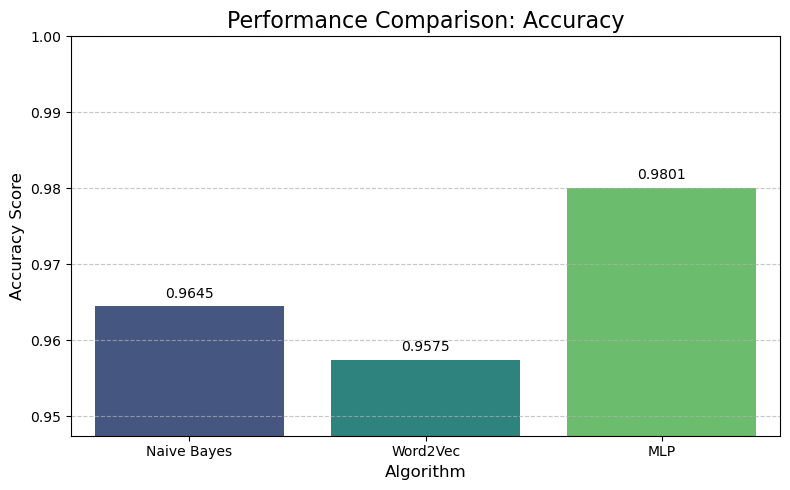

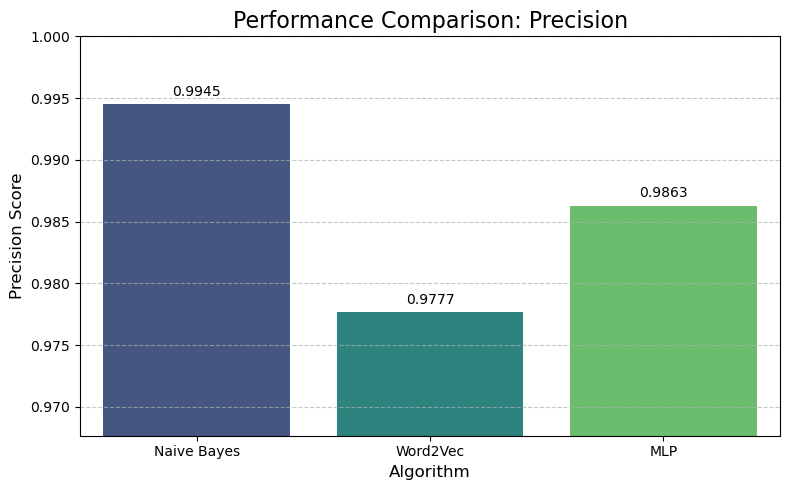

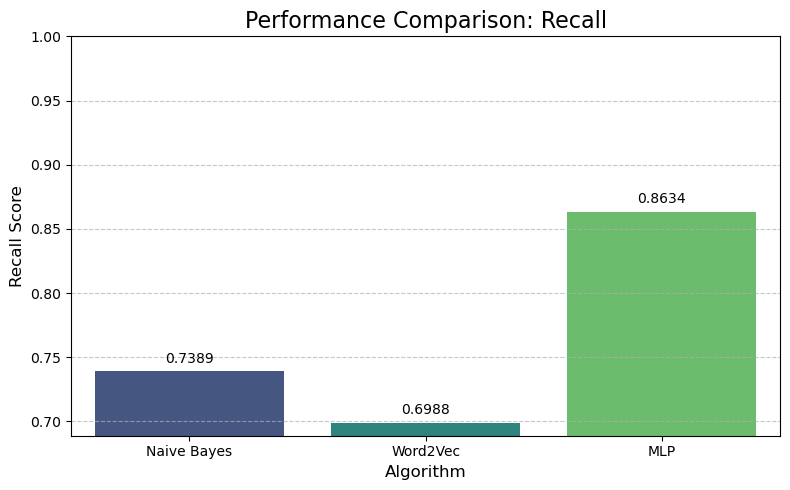

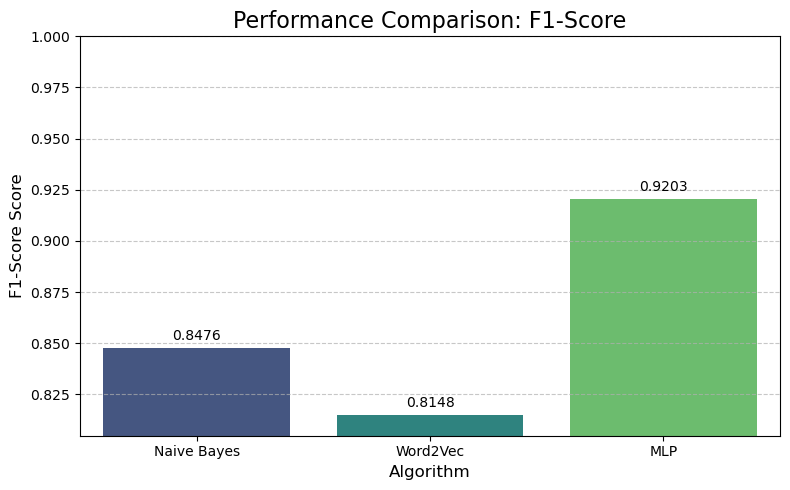

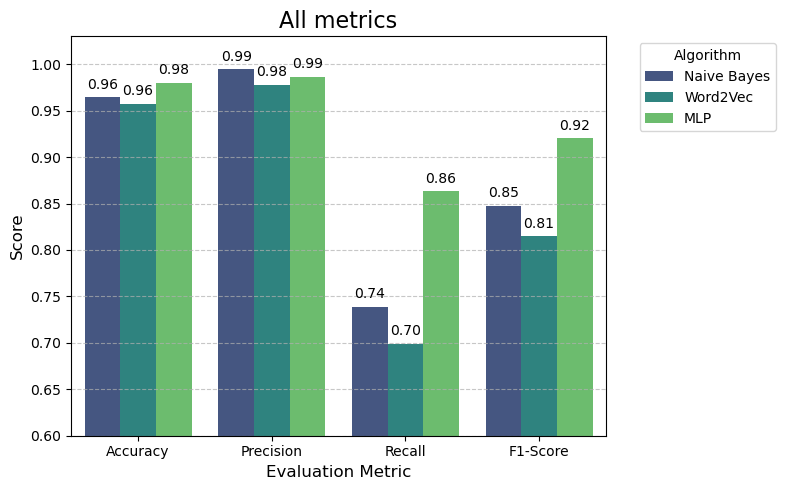

Training times (in seconds):
NB:0.0129
W2V:0.9235
MLP:61.4632
A Multi-Layered Perceptron is about 4781 times slower than Naive Bayes.


In [12]:
# Comparison of metrics
data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [np.mean(cv_results_nb['test_accuracy']), np.mean(cv_results_nb['test_precision']), np.mean(cv_results_nb['test_recall']), np.mean(cv_results_nb['test_f1'])],
    'Word2Vec': [np.mean(cv_results_lr['test_accuracy']), np.mean(cv_results_lr['test_precision']), np.mean(cv_results_lr['test_recall']), np.mean(cv_results_lr['test_f1'])],
    'MLP': [np.mean(cv_results_mlp['test_accuracy']), np.mean(cv_results_mlp['test_precision']), np.mean(cv_results_mlp['test_recall']), np.mean(cv_results_mlp['test_f1'])]
}
df = pd.DataFrame(data)

df_melted = df.melt(id_vars='Metric', var_name='Algorithm', value_name='Score')

# --- Create the Grouped Bar Chart ---
for metric in df_melted['Metric'].unique():
    plt.figure(figsize=(8, 5))
    df_metric = df_melted[df_melted['Metric'] == metric]
    ax = sns.barplot(x='Algorithm', y='Score', data=df_metric, palette='viridis')

    # Calculate the minimum score for the current metric
    min_score = df_metric['Score'].min()
    
    # Set the lower y-axis limit to be 0.1 less than the minimum score, but not below 0
    # We do this to "zoom in" on the results, and see the small differences.
    plt.ylim(max(0, min_score - 0.01), 1.0) 

    for p in ax.patches: #This displays the number on top of the bar.
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', 
                    xytext=(0, 9),
                    textcoords='offset points')
    
    plt.title(f'Performance Comparison: {metric}', fontsize=16)
    plt.xlabel('Algorithm', fontsize=12)
    plt.ylabel(f'{metric} Score', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Metric', y='Score', hue='Algorithm', data=df_melted, palette='viridis')

plt.title('All metrics', fontsize=16)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.6, 1.03)
for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
plt.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print(f"Training times (in seconds):\nNB:{nb_time:.4f}\nW2V:{lr_time:.4f}\nMLP:{mlp_time:.4f}")
print(f"A Multi-Layered Perceptron is about {mlp_time // nb_time:.0f} times slower than Naive Bayes.")

#### Βήμα 6: Συμπεράσματα
Σε κάθε μετρική που εξετάσαμε (πλην του χρόνου), βρήκαμε ότι το Word2Vec είναι πάντα ο λιγότερο αποδοτικός αλγόριθμος.\
Αυτό το αποτέλεσμα μπορεί να φαίνεται παράξενο, αλλά είναι λογικό εαν εξετάσουμε το database.\
\
Στα μηνύματα spam του database, σχεδόν πάντα υπάρχουν λέξεις-κλειδιά όπως "call", "text", και "click". Το Naive Bayes ειδικεύεται σε αυτού του είδους την ταξινόμηση, όπου υπάρχουν κάποιες ξεχωριστές λέξεις που σηματοδοτούν την κατηγορία του μηνύματος.\
Για αυτόν τον λόγο το Naive Bayes εμφανίζει υψηλό αριθμό False Negatives, καθως μηνύματα που δεν περιέχουν αυτές τις λέξεις περνάνε απαρατήρητα.\
Το Word2Vec, όμως, δημιουργόντας τα διανύσματα που χρησιμοποιεί για να ανιχνεύσει το είδος του μηνύματος, χάνει την σημασία αυτών των συγκεκριμένων λέξεων, καθως τις συνδέει με άλλες, πιο κοινότοπες λέξεις, που εμφανίζονται περισσότερο σε μηνύματα spam.\
\
Ένα άλλο πρόβλημα για το Word2Vec είναι το μέγεθος των μηνυμάτων. Ιδανικά, το Word2Vec χρειάζεται μεγάλες προτάσεις, ώστε να έχει το CBOW και Skip-gram λέξεις που να μπορεί να συγκρίνει με τις προβλέψεις του.\
Όμως, πολλά μηνύματα είναι μικρότερα από δέκα λέξεις, και το παράθυρο του Word2Vec έιναι πέντε λέξεις, που σημαίνει ότι συχνά το Word2Vec περιορίζεται και παράγει λιγότερο σωστά διανύσματα.\
\
Το Naive Bayes είναι δεύτερο σε απόδοση, με την αφέλειά του να λειτουργεί προς ώφελός του, αφού τα μηνύματα αυτού του dataset δεν έχουν ιδιαίτερη περιπλοκότητα και εντοπίζονται εύκολα.\
Αλλά, τα false negatives αποκαλύπτουν ότι δεν απαιτείται μεγάλη προσπάθεια για να παρακάμψει κάποιος το φίλτρο, και το Naive Bayes θα είχε χειρότερη απόδοση φιλτράροντας πιο σύγχρονα μηνύματα spam.\
\
Το MLP γενικότερα έχει την καλύτερη απόδοση, εκτός από την ακρίβεια. Πέρα από τα τωρινά αποτελέσματα, επειδή το MLP έχει την ικανότητα να μετεκπαιδευτεί πάνω σε ανάδραση από χρήστες, έχει καλύτερες πιθανότητες να διατηρήσει ή και να βελτιώσει την απόδοσή του, ενώ οι άλλοι αλγόριθμοι θα μείνουν πίσω.\
Το κόστος του MLP είναι υπολογιστικό και χρονικό. Η εκπαίδευσή του παίρνει 3607 φορές περισσότερο από την εκπαίδευση του Naive Bayes.\
\
Τελικά, αν και το MLP είναι αντικειμενικά ο καλύτερος αλγόριθμος, ίσως είναι υπερβολικός για ένα απλό spam filter. Ο Naive Bayes μπορεί να κάνει την ίδια δουλειά λίγο χειρότερα, σε ένα χιλιοστό του χρόνου.
